# Complexity of Quantum Annealing on 1D Ising

#### Imports

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from src.annealing_utils import get_driver_hamiltonian,get_longitudinal_hamiltonian,computational_basis
from src.schedule_utils import SchedulerModel,Schedule
from ManyBodyQutip.qutip_class import SpinOperator 
from src.utils import Sector

## Initialization of the target Hamiltonian

#### Hyperapameters

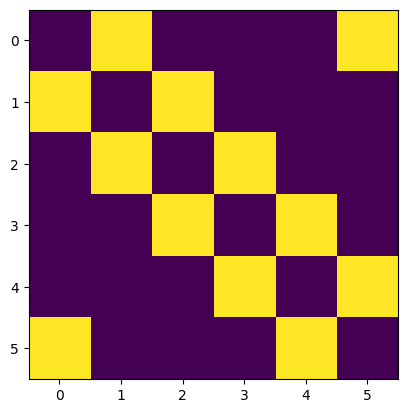

In [15]:
#### create istances on networkx
nqubits = 6

basis=computational_basis(nqubits)
graph_instance = nx.random_regular_graph(d=3, n=nqubits)

# Assign random weights in [0,1]
for u, v in graph_instance.edges():
    graph_instance[u][v]['weight'] = np.random.uniform(0, 1)
    
jij = np.roll(np.eye(nqubits),axis=1,shift=1)+np.roll(np.eye(nqubits),axis=1,shift=-1)

plt.imshow(jij)
plt.show()

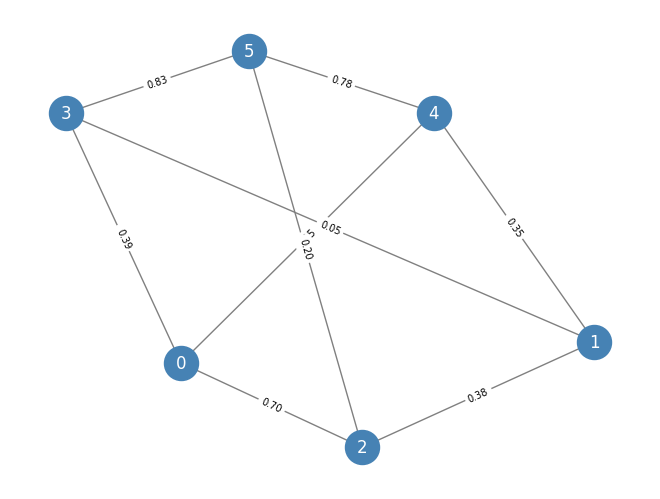

In [3]:

pos = nx.spring_layout(graph_instance, seed=42)
nx.draw(graph_instance, pos, with_labels=True, node_color='steelblue',
        edge_color='gray', node_size=600, font_color='white')

# draw edge weights
edge_labels = {(u,v): f"{graph_instance[u][v]['weight']:.2f}" for u,v in graph_instance.edges()}
nx.draw_networkx_edge_labels(graph_instance, pos, edge_labels=edge_labels, font_size=7)

plt.show()

#### Hamiltonian Initialization

In [16]:
nqubits=jij.shape[0]

PS=Sector(nqubits=nqubits)

target_hamiltonian=get_longitudinal_hamiltonian(jij)
target_hamiltonian_s=PS.project(target_hamiltonian)
driver_hamiltonian=get_driver_hamiltonian(nqubits=nqubits)

driver_hamiltonian_s=PS.project(driver_hamiltonian)


Sector: 32 states out of 64


#### Analysis of the spectrum of the target hamiltonian

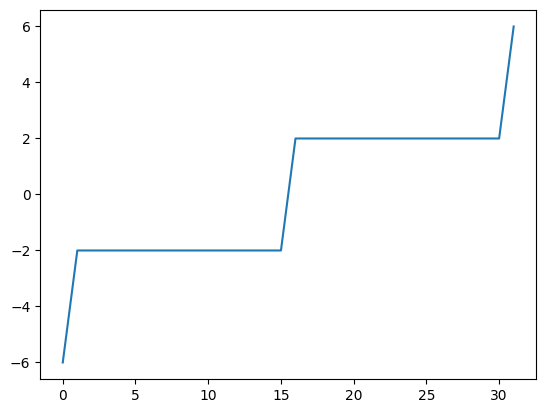

(-6+0j) (-2+0j) [0 1 0 1 0 1] [0 0 1 0 0 1]


In [17]:
values=target_hamiltonian_s.diagonal()

spectrum_target_hamiltonian_s=np.sort(values)
eigenstates_target_hamiltonian_s=basis[np.argsort(values)]

plt.plot(spectrum_target_hamiltonian_s)
plt.show()

print(spectrum_target_hamiltonian_s[0],spectrum_target_hamiltonian_s[1],eigenstates_target_hamiltonian_s[0],eigenstates_target_hamiltonian_s[1])

#### Time evolution

In [18]:
# ── time evolution parameters ─────────────────────────────────────────────────
nlevels    = 10
tau        = 5
time_steps = int(30 * tau)
time       = np.linspace(0, tau, time_steps)
delta_t    = time[1] - time[0]

In [19]:
from scipy.sparse.linalg import eigsh, expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
dim      = 2 ** nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)
psi_init=PS.project(psi_init)
print(psi_init.shape)
# ── initialization ────────────────────────────────────────────────────────────
spectrum            = np.zeros((time_steps, nlevels))
energy              = np.zeros(time_steps)
probabilities       = np.zeros((time_steps, nlevels))
psi_history          = np.zeros((time_steps, dim//2), dtype=complex)
eigenstates_history = np.zeros((time_steps, dim//2, nlevels), dtype=complex)

eigenstates_prev = None
psi = psi_init.copy()

# ── time evolution ────────────────────────────────────────────────────────────
for i, t in enumerate(time):
    hamiltonian_t = (1 - t / tau) * driver_hamiltonian_s + (t / tau) * target_hamiltonian_s
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)


    # ── diagonalize ───────────────────────────────────────────────────────
    spectrum_t, eigenstates_t = eigsh(hamiltonian_t.astype(complex), which='SA', k=nlevels)
    order              = np.argsort(spectrum_t)
    spectrum[i]        = spectrum_t[order]
    eigenstates_raw    = eigenstates_t[:, order].astype(complex)  # raw — for probabilities
    eigenstates_history[i] = eigenstates_raw
    # overlap
    probabilities[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_raw)*np.einsum('i,ia->a',psi.conj(),eigenstates_raw).conj()
    energy[i] = np.real(np.vdot(psi, hamiltonian_t @ psi))
    psi_history[i] = psi

print(probabilities[-1])
print(spectrum.shape)
print(time[np.argmin(spectrum[:,2]-spectrum[:,0])],np.min(spectrum[:,2]-spectrum[:,0]))

min_time_gap= time[np.argmin(spectrum[:,2]-spectrum[:,0])]

(32,)


/tmp/ipykernel_88884/3541074027.py:31: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_raw)*np.einsum('i,ia->a',psi.conj(),eigenstates_raw).conj()


[0.57401715 0.01037517 0.03043762 0.02687166 0.00318819 0.03131622
 0.01043795 0.02152806 0.05804848 0.07471849]
(150, 10)
1.912751677852349 1.204208033043869


Check the results

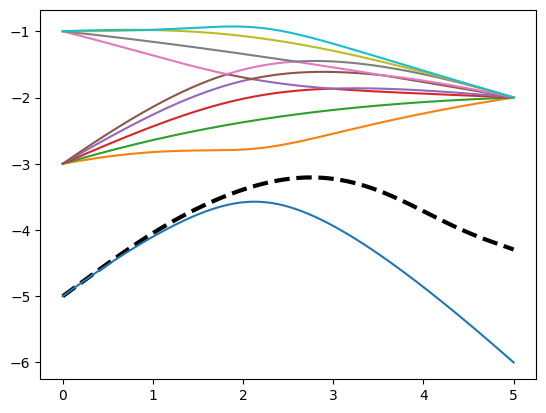

In [20]:

plt.plot(time,energy,color='black',linestyle='--',linewidth=3)
for i in range(spectrum.shape[1]):
        plt.plot(time,spectrum[:,i])

plt.show()

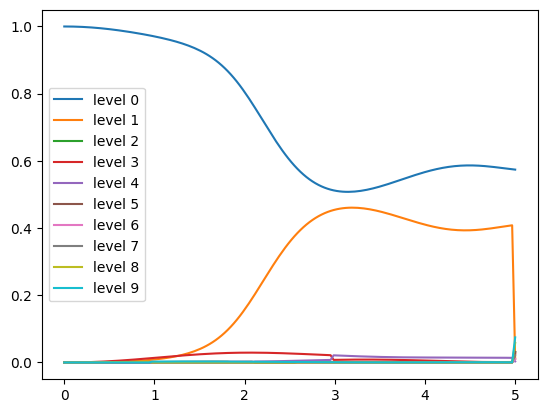

In [21]:
for i in range(nlevels):
    plt.plot(time,probabilities[:,i],label=f'level {i}')

plt.legend()
plt.show()

#### Compute Measure of Stabilizerness

In [22]:
from src.jax_utils import SREJax
from tqdm import trange

# build once — reuse for all states
sre = SREJax(n_qubits=nqubits, batch_size=4096)

# single state
magic=[]
magic_gs_level=[]
for i in trange(time_steps):
    state=psi_history[i]
    magic.append(sre(PS.lift(state)))
    magic_gs_level.append(sre(PS.lift(eigenstates_history[i,:,0])))

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Building Pauli tables for n=6 (4096 Paulis)...
Done.


100%|██████████| 150/150 [00:00<00:00, 373.60it/s]


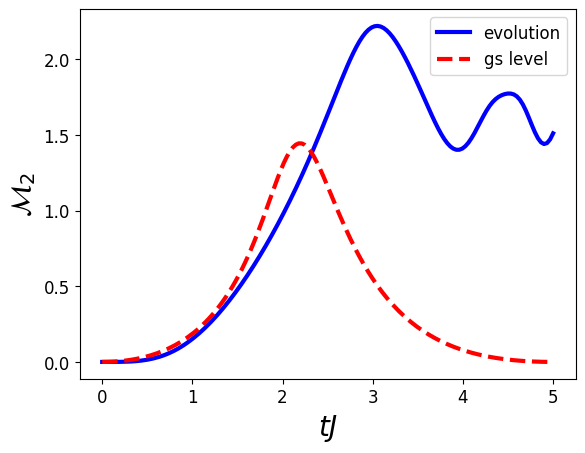

In [23]:
plt.plot(time,magic,label='evolution',color='blue',linestyle='-',linewidth=3)
plt.plot(time,magic_gs_level,label='gs level',color='red',linestyle='--',linewidth=3)
plt.xlabel(r'$t J$',fontsize=20)
plt.ylabel(r'$\mathcal{M}_2$',fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

In [11]:

from curses.ascii import SP


_,eigenstates_target_hamiltonian=eigsh(target_hamiltonian_s.astype(complex), which='SA', k=4)
print(sre(PS.lift(eigenstates_target_hamiltonian[:,0]))) 

0.0


## Optimal Control Method

##### Get Hyperparameters

In [12]:
number_parameters=5
type='F-CRAB'

In [13]:
from scipy.optimize import minimize

model=SchedulerModel(target_hamiltonian=target_hamiltonian_s,initial_hamiltonian=driver_hamiltonian_s,tf=tau,nsteps=time_steps,number_of_parameters=number_parameters,type=type,seed=42,reference_hamiltonian=target_hamiltonian_s,mode='annealing ansatz')



res = minimize(
                    model.forward,
                    model.parameters,
                    method='L-BFGS-B',
                    tol=10**-6,
                    callback=model.callback,
                    options=None,
                    
                )

model.parameters = res.x
energy = model.forward(model.parameters)

-4.655432916479949
-4.903679893910576
-5.042616320002215


KeyboardInterrupt: 

#### Jax optimization (optional)

In [17]:
from src.jax_utils import JaxSchedulerModel, JaxTrainer

model = JaxSchedulerModel(
    initial_state=psi_init,
    target_hamiltonian=target_hamiltonian_s,
    initial_hamiltonian=driver_hamiltonian_s,
    reference_hamiltonian=target_hamiltonian_s,
    tf=tau,
    nsteps=time_steps,
    number_of_parameters=number_parameters,
    type=type,
    seed=42,
    mode='annealing ansatz',
    random=True,
)

trainer = JaxTrainer(model, maxiter=1000, tol=1e-6, ftol=1e-9, gtol=1e-6, verbose=True)
results = trainer.run()

h_driver  = results['h_driver']
h_target  = results['h_target']
psi_final = results['psi']
energy    = results['energy']   # already in physical units

JIT compilation done.
-3.8995116172382835
-4.215003451364644
-4.463822213554888
-4.614642300328884
-4.664701821932338
-4.769546592310574
-4.888825454592878
-4.991162628317237
-5.0957674460339035
-5.192211112057695
-5.231061789583898
-5.289622546652559
-5.319585827551981
-5.365067263258464
-5.443230100834262
-5.545249674293303
-5.583319749307197
-5.636559181857444
-5.656882933186602
-5.697269096331158
-5.728135327450281
-5.768971234344783
-5.818273272160586
-5.838388953453658
-5.846497403920715
-5.849977223307159
-5.854084221731777
-5.865672627353218
-5.873813761336861
-5.879745776683624
-5.8863609728983874
-5.890250205741032
-5.896207612769904
-5.940719428860768
-5.946284319695972
-5.9680133665576145
-5.9863041490640905
-5.988144967811471
-5.989289942510425
-5.990958327721326
-5.9913754022421335
-5.992486509100784
-5.993056919919827
-5.994339619793987
-5.994835152595468
-5.995525221204645
-5.996018016821241
-5.996323878853912
-5.99654204797644
-5.996565542938642
-5.996768500193888
-5.9

KeyboardInterrupt: 

#### Check the results

(36.87448958723804+0.7356654206763142j)


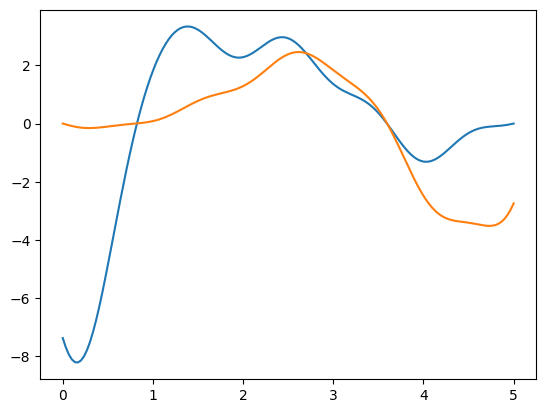

(-5.999346803475872+0j)


In [18]:
# ── energy + state history for both schedules ─────────────────────────────────
energy_linear  = np.zeros(time_steps)
energy_optimal = np.zeros(time_steps)
psi_linear_history  = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
psi_optimal_history = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)

# optimal
h_driver, h_target = model.get_driving()

# initialize the state
_, psi = eigsh(driver_hamiltonian_s.astype(complex), which='SA', k=1)
psi_init = psi[:, 0].astype(complex)
print(psi_init.dot(h_driver[0]*driver_hamiltonian_s.dot(psi_init)))

plt.plot(time,h_driver)
plt.plot(time,h_target)
plt.show()





# initialization
psi=psi_init.copy()
psi_history_optimalcontrol=np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
for i,t in enumerate(time):
    
    hamiltonian_t=h_driver[i]*driver_hamiltonian_s+target_hamiltonian_s*h_target[i]
    psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
    psi_history_optimalcontrol[i]=psi
    #for r in range(nlevels):
    #    probabilities_optimalcontrol[i,r]=(eigenstates_history[i,:,r].conj().T.dot(psi))*np.conjugate((eigenstates_history[i,:,r].conj().T.dot(psi)))

print(psi.conj().dot(target_hamiltonian_s.dot(psi)))

In [19]:


# initialization
energy_optimal=np.zeros(time_steps)
probabilities_optimalcontrol=np.zeros((time_steps,nlevels))
spectrum_optimalcontrol=np.zeros((time_steps,nlevels))
for i,t in enumerate(time):
    psi=psi_history_optimalcontrol[i]     
    hamiltonian_t=(1-t/tau)*driver_hamiltonian_s+target_hamiltonian_s*t/tau
    values, eigenstates = eigsh(hamiltonian_t, which='SA', k=nlevels)
    order = np.argsort(values)
    spectrum_t    = values[order]
    eigenstates_t = eigenstates[:, order]
    spectrum_optimalcontrol[i]=spectrum_t
    # overlap
    probabilities_optimalcontrol[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()
    energy_optimal[i]=psi.conj().dot(hamiltonian_t.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian_s.dot(psi)))
print(probabilities_optimalcontrol[-1,0])

/tmp/ipykernel_87290/2306226813.py:14: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_optimalcontrol[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()
/tmp/ipykernel_87290/2306226813.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_optimal[i]=psi.conj().dot(hamiltonian_t.dot(psi))


5.0
(-5.999346803475872+0j)
0.9998367019542032


In [20]:
print(spectrum_optimalcontrol[-1])

[-6. -2. -2. -2. -2. -2. -2. -2. -2. -2.]


0
-5.999999999999989
1
-2.000000000000001
2
-2.000000000000001
3
-2.0000000000000004
4
-2.0000000000000004
5
-2.0000000000000004
6
-2.0
7
-1.9999999999999993
8
-1.9999999999999993
9
-1.9999999999999991


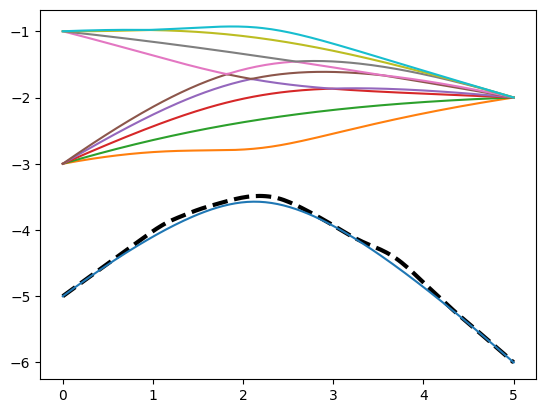

In [21]:

plt.plot(time,energy_optimal,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_optimalcontrol.shape[1]):
        print(i)
        print(spectrum_optimalcontrol[-1,i])
        plt.plot(time,spectrum_optimalcontrol[:,i])

plt.show()

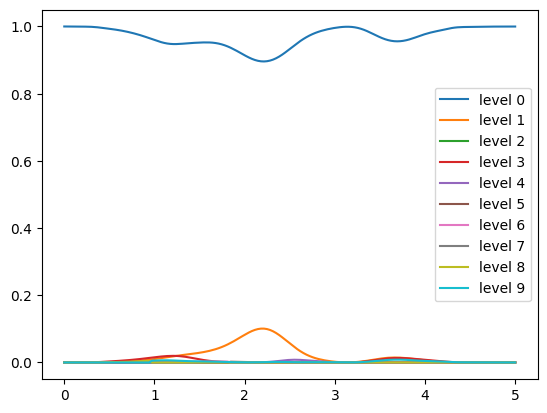

In [22]:
for i in range(nlevels):
    plt.plot(time,probabilities_optimalcontrol[:,i],label=f'level {i}')

plt.legend()
plt.show()

##### Stabilizer Renyi Entropy

In [14]:
# single state
magic_optimal_control=[]
for i in trange(time_steps):
    state=psi_history_optimalcontrol[i]
    magic_optimal_control.append(sre(PS.lift(state)))

  0%|          | 0/150 [00:00<?, ?it/s]


NameError: name 'psi_history_optimalcontrol' is not defined

ValueError: x and y must have same first dimension, but have shapes (150,) and (0,)

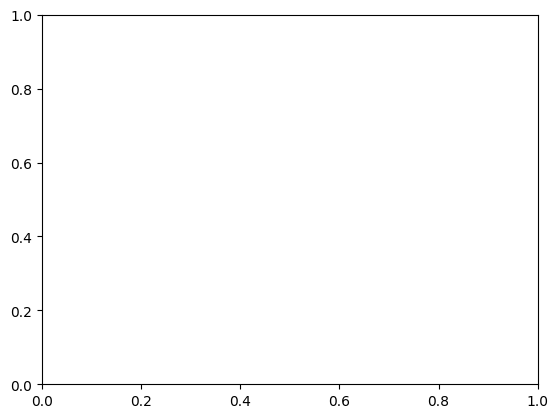

In [15]:
plt.plot(time,magic_optimal_control)
plt.plot(time,magic_gs_level)
plt.plot(time,magic)
plt.show()

## CounterAdiabatic Driving

##### We should be more careful about the CounterAdiabatic Driving, we need to be sure on the structure

Let's initialize the Catalyst term

In [24]:
from src.annealing_utils import get_unbiased_catalyst_term
from src.annealing_utils import get_counteradiabatic_term

counteradiabatic_term=get_counteradiabatic_term(driver_hamiltonian=driver_hamiltonian,target_hamiltonian=target_hamiltonian)
counteradiabatic_term_s=PS.project(counteradiabatic_term)
print(counteradiabatic_term)

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 192 stored elements and shape (64, 64)>
  Coords	Values
  (0, 1)	4j
  (0, 2)	4j
  (0, 4)	4j
  (0, 8)	4j
  (0, 16)	4j
  (0, 32)	4j
  (1, 0)	(-0-4j)
  (1, 5)	4j
  (1, 9)	4j
  (1, 17)	4j
  (2, 0)	(-0-4j)
  (2, 10)	4j
  (2, 18)	4j
  (2, 34)	4j
  (3, 11)	4j
  (3, 19)	4j
  (4, 0)	(-0-4j)
  (4, 5)	4j
  (4, 20)	4j
  (4, 36)	4j
  (5, 1)	(-0-4j)
  (5, 4)	(-0-4j)
  (5, 7)	(-0-4j)
  (5, 21)	4j
  (6, 22)	4j
  :	:
  (57, 41)	4j
  (58, 42)	4j
  (58, 56)	(-0-4j)
  (58, 59)	(-0-4j)
  (58, 62)	(-0-4j)
  (59, 27)	4j
  (59, 43)	4j
  (59, 58)	4j
  (59, 63)	(-0-4j)
  (60, 44)	4j
  (60, 52)	4j
  (61, 29)	4j
  (61, 45)	4j
  (61, 53)	4j
  (61, 63)	(-0-4j)
  (62, 46)	4j
  (62, 54)	4j
  (62, 58)	4j
  (62, 63)	(-0-4j)
  (63, 31)	4j
  (63, 47)	4j
  (63, 55)	4j
  (63, 59)	4j
  (63, 61)	4j
  (63, 62)	4j


Compute the optimal driving of the adiabatic gauge potential from calculations

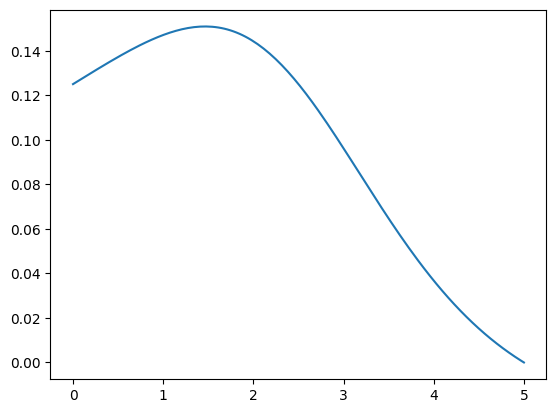

In [26]:
def optimal_alpha(J, lam):
    """
    Optimal alpha_0(lambda) from minimizing Tr[G_lambda^2].
    """
    J2       = np.sum(J ** 2)                          # ||J||^2
    J2_row   = np.sum(J ** 2, axis=1)                  # (n,): sum_B J_AB^2
    J4_sum   = np.sum(J2_row ** 2)                     # sum_A (sum_B J_AB^2)^2

    numerator   = 4 * (1 - lam) * J2
    denominator = 32 * (1 - lam)**2 * J2 + 16 * lam**2 * J4_sum

    if np.abs(denominator) < 1e-12:
        return 0.0
    return -numerator / denominator

# schedule of alpha_0 along the annealing
alpha = -1*np.array([optimal_alpha(jij, s) for s in time / tau])

plt.plot(time,alpha)
plt.show()

In [32]:
from scipy.sparse.linalg import eigsh,expm_multiply
from src.annealing_utils import compute_exact_AGP
# ── initial state ─────────────────────────────────────────────────────────────
dim      = 2 ** nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)
psi_init=PS.project(psi_init)

# initialization

psi=psi_init.copy()
psi_history_counteradiabatic=np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
spectrum_counteradiabatic=np.zeros((time_steps,nlevels))
energy_counteradiabatic=np.zeros(time_steps)
for i,t in enumerate(time):
    exact_AGP=compute_exact_AGP(driver_hamiltonian=driver_hamiltonian_s,target_hamiltonian=target_hamiltonian_s,lam=t/tau,n_eigs=2)
    hamiltonian_t=(1-t/tau)*driver_hamiltonian_s+target_hamiltonian_s*t/tau+(1/tau)*exact_AGP
    psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
    spectrum_t,_=eigsh(hamiltonian_t,which='SA',k=nlevels)
    order = np.argsort(spectrum_t)
    spectrum_t    = spectrum_t[order]
    spectrum_counteradiabatic[i]=spectrum_t
    energy_counteradiabatic[i]=psi.conj().dot(hamiltonian_t.dot(psi))
    # sort both by eigenvalue
    psi_history_counteradiabatic[i]=psi


/tmp/ipykernel_88884/3044621191.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_counteradiabatic[i]=psi.conj().dot(hamiltonian_t.dot(psi))


In [33]:

# initialize the state


# initialization
energy_counteradiabatic_linear_hamiltonian=np.zeros(time_steps)
probabilities_counteradiabatic=np.zeros((time_steps,nlevels))
for i,t in enumerate(time):
    psi=psi_history_counteradiabatic[i]     
    hamiltonian_t_linear=(1-t/tau)*driver_hamiltonian_s+target_hamiltonian_s*t/tau
    values, eigenstates = eigsh(hamiltonian_t_linear, which='SA', k=nlevels)
    order = np.argsort(values)
    spectrum_t    = values[order]
    eigenstates_t = eigenstates[:, order]
    # overlap
    probabilities_counteradiabatic[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()

    energy_counteradiabatic_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian_s.dot(psi)))
print(energy_counteradiabatic_linear_hamiltonian[-1])
print(probabilities_counteradiabatic[-1,0])

/tmp/ipykernel_88884/1932926314.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_counteradiabatic[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()
/tmp/ipykernel_88884/1932926314.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_counteradiabatic_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))


5.0
(-5.868832968692346+0j)
-5.868832968692346
0.9676865764638647


##### Results of the unbiased counteradiabatic term

0
-5.999999999999999
-5.868832968692346
1
-2.000000000000001
-5.868832968692346
2
-2.0000000000000004
-5.868832968692346
3
-2.0
-5.868832968692346
4
-2.0
-5.868832968692346
5
-2.0
-5.868832968692346
6
-2.0
-5.868832968692346
7
-1.9999999999999996
-5.868832968692346
8
-1.9999999999999991
-5.868832968692346
9
-1.9999999999999991
-5.868832968692346


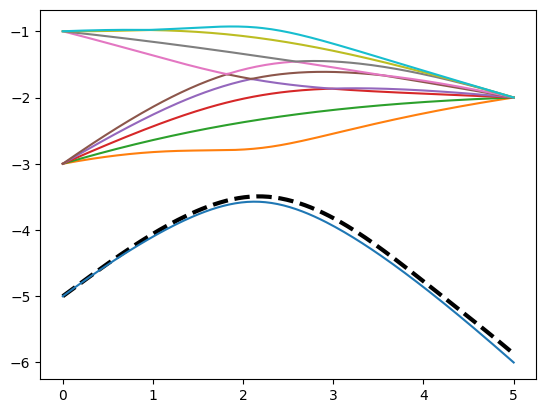

0
-6.000014964195008
1
-2.0000000000000018
2
-2.000000000000001
3
-2.0000000000000004
4
-2.0
5
-2.0
6
-1.9999999999999998
7
-1.9999999999999998
8
-1.9999999999999996
9
-1.9999999999999987


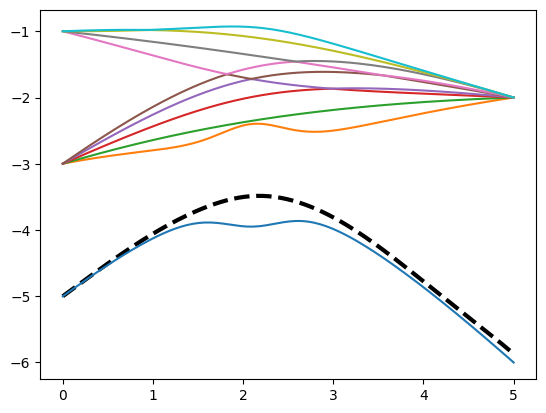

In [34]:

plt.plot(time,energy_counteradiabatic_linear_hamiltonian,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_counteradiabatic.shape[1]):        
        print(i)
        print(spectrum[-1,i])
        print(energy_counteradiabatic_linear_hamiltonian[-1])
        plt.plot(time,spectrum[:,i])

plt.show()

plt.plot(time,energy_counteradiabatic,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_counteradiabatic.shape[1]):

        print(i)
        print(spectrum_counteradiabatic[-1,i])
        plt.plot(time,spectrum_counteradiabatic[:,i])

plt.show()


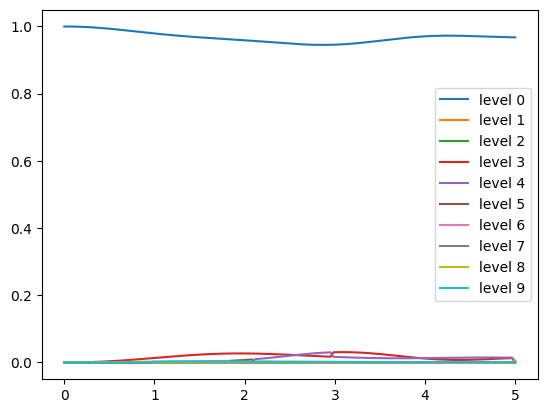

In [35]:
for i in range(nlevels):
    plt.plot(time,probabilities_counteradiabatic[:,i],label=f'level {i}')

plt.legend()
plt.show()

##### Measure of Stabilizerness

In [36]:
# single state
magic_counteradiabatic=[]

for i in trange(time_steps):
    state=psi_history_counteradiabatic[i]
    magic_counteradiabatic.append(sre(PS.lift(state)))


100%|██████████| 150/150 [00:00<00:00, 865.01it/s]


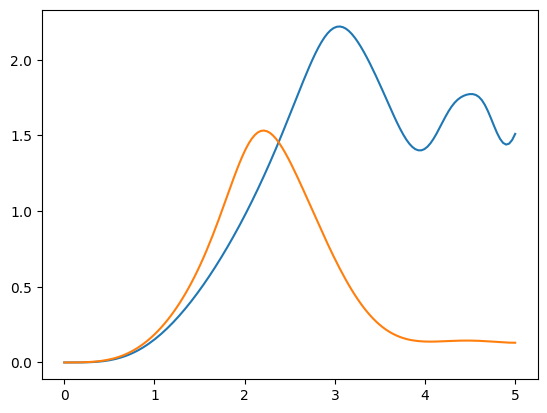

In [38]:
plt.plot(time,magic)
#plt.plot(time,magic_optimal_control)
plt.plot(time,magic_counteradiabatic)
plt.show()

## Non-stoquastic Driving

##### We should be more careful about the CounterAdiabatic Driving, we need to be sure on the structure

Let's initialize the Catalyst term

In [100]:
from src.annealing_utils import get_unbiased_catalyst_term
from src.annealing_utils import get_counteradiabatic_term
from ManyBodyQutip.qutip_class import SpinOperator

nonstoquastic_driving=0.
for i in range(nqubits):
    for j in range(i+1,nqubits):
        nonstoquastic_driving+=SpinOperator(index=[('x',i,'x',j)],coupling=[-1],size=nqubits).qutip_op.data_as('csr_matrix')
        nonstoquastic_driving+=SpinOperator(index=[('y',i,'y',j)],coupling=[-1],size=nqubits).qutip_op.data_as('csr_matrix')

nonstoquastic_driving_s=PS.project(nonstoquastic_driving)

In [ ]:
from scipy.sparse.linalg import eigsh,expm_multiply

# combined driver: H_D + beta * H_NS
beta           = 1
total_driver_ns    = (driver_hamiltonian_s + beta * nonstoquastic_driving_s)/(1+beta)

# GS is now well-defined if H_driver_ns is not degenerate
evals, evecs   = eigsh(total_driver_ns.astype(complex), which='SA', k=2)
order          = np.argsort(evals)
evals          = evals[order]
evecs          = evecs[:, order]

print(f'Lowest 2 levels: {evals}')   # check for degeneracy
print(f'Gap: {evals[1]-evals[0]:.6f}')

psi_init       = evecs[:, 0].astype(complex)
e_check        = (psi_init.conj() @ total_driver_ns @ psi_init).real
print(f'GS energy check: {e_check:.6f}')   # should match evals[0]

# initialization

psi=psi_init
psi_history_catalyst=np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
spectrum_catalyst=np.zeros((time_steps,nlevels))
energy_catalyst=np.zeros(time_steps)
for i,t in enumerate(time):
    psi_history_catalyst[i]=psi
    hamiltonian_t=(1-t/tau)*total_driver_ns+target_hamiltonian_s*t/tau
    psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
    spectrum_t,_=eigsh(hamiltonian_t,which='SA',k=nlevels)
    order = np.argsort(spectrum_t)
    spectrum_t    = spectrum_t[order]
    spectrum_catalyst[i]=spectrum_t
    energy_catalyst[i]=psi.conj().dot(hamiltonian_t.dot(psi))
    # sort both by eigenvalue
    


Lowest 2 levels: [-16.03574114 -11.55890463]
Gap: 4.476837
GS energy check: -16.035741


/tmp/ipykernel_88884/2837839220.py:34: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_catalyst[i]=psi.conj().dot(hamiltonian_t.dot(psi))


In [116]:

# initialize the state


# initialization
energy_catalyst_linear_hamiltonian=np.zeros(time_steps)
probabilities_nonstoquastic=np.zeros((time_steps,nlevels))
for i,t in enumerate(time):
    psi=psi_history_catalyst[i]     
    hamiltonian_t_linear=(1-t/tau)*total_driver_ns+target_hamiltonian_s*t/tau
    values, eigenstates = eigsh(hamiltonian_t_linear, which='SA', k=nlevels)
    order = np.argsort(values)
    spectrum_t    = values[order]
    eigenstates_t = eigenstates[:, order]
    # overlap
    probabilities_nonstoquastic[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()
    
    energy_catalyst_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian_s.dot(psi)))
print(probabilities_nonstoquastic[-1,0])

5.0
(-4.815354909686159+0j)
0.7066252529643072


/tmp/ipykernel_88884/2405594016.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_nonstoquastic[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()
/tmp/ipykernel_88884/2405594016.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_catalyst_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))


##### Results of the unbiased catalyst

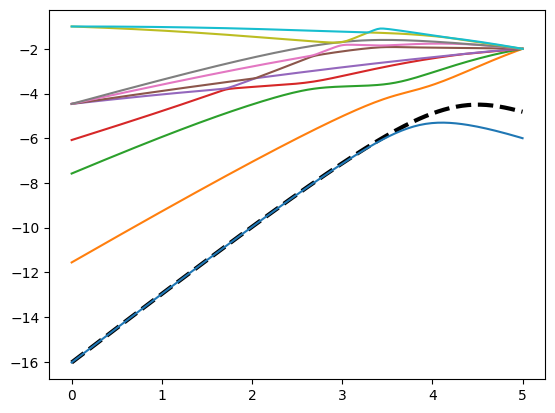

In [117]:

plt.plot(time,energy_catalyst,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_catalyst.shape[1]):

        plt.plot(time,spectrum_catalyst[:,i])

plt.show()



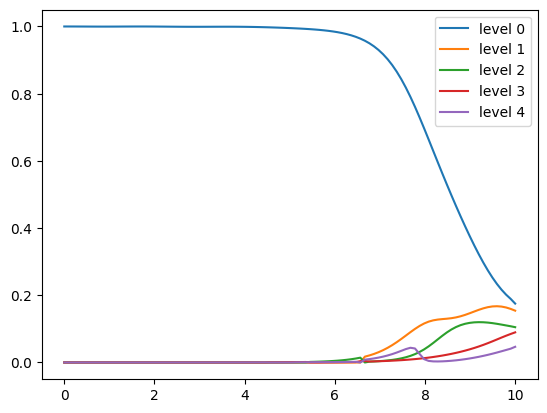

In [95]:
for i in range(nlevels//2):
    plt.plot(time,probabilities_catalyst[:,i],label=f'level {i}')

plt.legend()
plt.show()